Model Integration with OpenAI, Gemini, and Groq

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [3]:
from langchain.chat_models import init_chat_model

model = init_chat_model("gpt-4.1")
model

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0', 'langchain-openai': '1.6.2'}}, profile={'name': 'GPT-4.1', 'release_date': '2025-04-14', 'last_updated': '2025-04-14', 'open_weights': False, 'max_input_tokens': 1047576, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x00000265918C1790>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000002659338DF90>, root_client=<openai.OpenAI object at 0x00000265918C1710>, r

In [4]:
## invoke the model
response = model.invoke("Hello, How are you")
response

OpenAIRateLimitError: Error code: 429 - {'error': {'message': 'You have no credits remaining. Add credits to continue using the API at https://platform.openai.com/settings/organization/billing/.', 'type': 'insufficient_quota', 'param': None, 'code': 'credit_balance_exhausted'}}

GOOGLE GEMINI Model

In [5]:
import os
from langchain.chat_models import init_chat_model

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

model = init_chat_model("google_genai:gemini-3.5-flash-lite")
response = model.invoke("How to build ai agents")
response.content

[{'type': 'text',
  'text': 'Building AI agents has become much easier thanks to advanced Large Language Models (LLMs) like GPT-4, Claude 3.5, and open-source models like Llama 3. \n\nAn **AI agent** is different from a simple chatbot. While a chatbot just responds to prompts, an agent has a **goal**, can **reason** through a problem, use **tools** (like web search or calculators), and **execute tasks autonomously**.\n\nHere is a step-by-step guide to building an AI agent, from conceptualization to deployment.\n\n---\n\n### Phase 1: Understand the Core Anatomy of an Agent\nTo build an agent, you need to understand its four main components:\n1. **The Brain (LLM):** The core intelligence that processes information and decides what to do next.\n2. **Planning:** The ability to break down a large goal into smaller steps (and self-correct when things go wrong).\n3. **Memory:** \n   * *Short-term memory:* Remembering the current conversation/task context.\n   * *Long-term memory:* Retaining i

In [31]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model = "gemini-3.5-flash-lite")
response = model.invoke("How to build ai agents")
response.content

[{'type': 'text',
  'text': 'Building AI agents has become much easier thanks to advanced Large Language Models (LLMs) like GPT-4, Claude, and open-source models, combined with powerful orchestration frameworks. \n\nAn **AI agent** differs from a simple chatbot because it has **autonomy**: it can perceive its environment, make a plan, use tools (like web search or calculators), and execute tasks to achieve a specific goal.\n\nHere is a step-by-step guide to building AI agents, from concepts to code.\n\n---\n\n### Phase 1: Understand the Anatomy of an Agent\nEvery functional AI agent has four core components:\n1. **The Brain (LLM):** The core intelligence that processes information, makes decisions, and generates responses.\n2. **Planning:** The ability to break down a large goal into smaller steps (e.g., "To write a market report, I first need to search the web, then summarize the findings, then format the output").\n3. **Memory:** \n   * *Short-term memory:* Remembering the current co

In [11]:
### using chatopenai instead of init_Chat_model
from langchain_openai import ChatOpenAI
model = ChatOpenAI(model = "gpt-4.1")
response = model.invoke("Hey, how to use chat gemini instead of init_chat_model")

OpenAIRateLimitError: Error code: 429 - {'error': {'message': 'You have no credits remaining. Add credits to continue using the API at https://platform.openai.com/settings/organization/billing/.', 'type': 'insufficient_quota', 'param': None, 'code': 'credit_balance_exhausted'}}

GROQ Model Integration

In [39]:
import requests
import os

url = "https://api.groq.com/openai/v1/models"
headers = {"Authorization": f"Bearer {os.getenv('GROQ_API_KEY')}"}

resp = requests.get(url, headers=headers).json()
for m in resp.get("data", []):
    print(m["id"])


openai/gpt-oss-120b
allam-2-7b
groq/compound
openai/gpt-oss-20b
qwen/qwen3.8-27b
canopylabs/orpheus-v1-english
whisper-large-v3-turbo
openai/gpt-oss-safeguard-20b
qwen/qwen3.6-27b
meta-llama/llama-prompt-guard-2-86m
groq/compound-mini
whisper-large-v3
canopylabs/orpheus-arabic-saudi
meta-llama/llama-prompt-guard-2-22m


In [23]:
import os
from langchain.chat_models import init_chat_model
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

model = init_chat_model("groq:groq/compound-mini")
response = model.invoke("How to build ai agents")
response.content


'Below is a practical, step‑by‑step roadmap you can follow to create your own AI‑driven software agents.  \nFeel free to pick the pieces that fit your project and skip the rest.\n\n---\n\n## 1. Clarify the Agent’s Goal & Scope\n| Question | Why it matters |\n|----------|----------------|\n| **What problem am I solving?** | Determines the required capabilities (e.g., answering questions, automating a workflow, controlling a robot). |\n| **What inputs will the agent receive?** | Text, voice, sensor data, API calls, etc. |\n| **What outputs are expected?** | Text response, action command, UI update, external API call. |\n| **What constraints exist?** | Latency, privacy, compute budget, safety rules. |\n\nWrite a short **spec sheet** (one paragraph + bullet list) that captures these answers. It will guide every later decision.\n\n---\n\n## 2. Choose the Core Model(s)\n\n| Option | When to use | Typical size | Cost / latency |\n|--------|-------------|--------------|----------------|\n| **O

In [19]:
import os
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

model = ChatGroq(model = "groq/compound-mini")
response = model.invoke("How to build ai agents")
response.content

'## Building an AI Agent – A Step‑by‑Step Guide\n\nBelow is a practical roadmap you can follow whether you’re creating a simple chatbot or a more sophisticated autonomous “agent” that can plan, act, and learn in an environment.\n\n---\n\n### 1️⃣ Clarify the Agent’s Goal & Scope\n| Question | What to Decide |\n|----------|----------------|\n| **What problem does it solve?** | E.g., answer customer support queries, schedule meetings, fetch data, play a game. |\n| **What actions can it take?** | Purely textual replies, API calls, UI interactions, robot control, etc. |\n| **What constraints exist?** | Latency, privacy, cost, safety, domain‑specific regulations. |\n\n**Output:** A concise “mission statement” (e.g., *“An AI assistant that can read a user’s calendar, suggest meeting times, and send invitations via Outlook.”*)\n\n---\n\n### 2️⃣ Choose the Core Architecture\n| Architecture | When to Use | Typical Stack |\n|--------------|------------|----------------|\n| **LLM‑only (prompt‑driv

STREAMING and BATCH

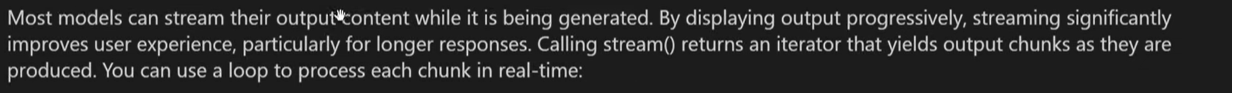

In [32]:
model.invoke("Write 200 words about investing")

AIMessage(content=[{'type': 'text', 'text': 'Investing is the powerful art of putting your money to work with the expectation of generating a financial return. Unlike saving, which merely stores your wealth, investing leverages the mechanisms of compound interest and economic growth to help your money multiply over time. \n\nAt its core, investing involves purchasing assets such as stocks, bonds, real estate, or mutual funds. Stocks offer ownership in growing corporations, providing potential for high returns alongside market volatility. Bonds act as loans to governments or companies, offering steady, lower-risk income. Real estate provides both tangible property value and potential rental income. \n\nThe secret to successful investing is not timing the market, but time *in* the market. By starting early, even small contributions can snowball into significant wealth thanks to compounding—where your earnings generate their own earnings. However, investing always carries risk; the potent

In [33]:
for chunk in model.stream("Write 200 words about investing"):
    print(chunk.text, end="|",flush=True)

Investing is| the powerful process of committing money with the expectation of generating a financial return or growing| wealth over time. Unlike simply saving money in a traditional bank account—where inflation slowly erodes purchasing power—investing puts| your capital to work in assets like stocks, bonds, real estate, or mutual funds. 

At the heart of successful| investing lies the magic of compound interest. By reinvesting your earnings, your money begins to generate its own returns, creating a snowball| effect that accelerates wealth accumulation over the long term. However, this growth comes with a trade-off: risk. Every| investment carries the possibility of losing money, and generally, the higher the potential return, the higher the associated risk.

To| navigate this landscape wisely, smart investors rely on diversification. By spreading investments across different asset classes, industries, and geographic regions, you can cushion| the blow of market downturns. Furthermore, 

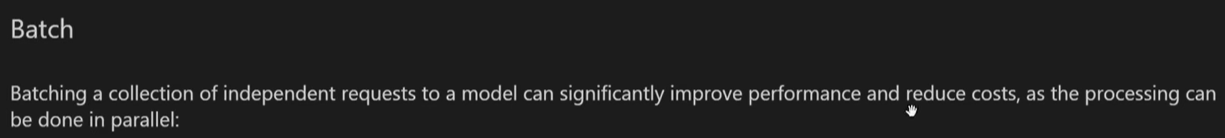

In [38]:
responses = model.batch([
    "Are Ai Agents self sufficient?"
    "Should we build agents?"
    "Do they posses great power?"],
    config={
        'max_concurrency': 5,
    }
)

for response in responses:
    print(response.content)
    print("\n" + "-"*50 + "\n")

[{'type': 'text', 'text': 'These are the three fundamental questions defining the current era of artificial intelligence. To answer them accurately, we have to look past the marketing hype and examine the actual technology as it stands today.\n\nHere is a breakdown of each question.\n\n---\n\n### 1. Are AI Agents self-sufficient?\n**Short answer: No, not yet.**\n\nWhile autonomous agents can string together multiple steps to achieve a goal (like researching a topic, writing code, and debugging it), they are far from truly self-sufficient in the wild. \n\n*   **Where they struggle:** They lack genuine common sense, long-term memory, and the ability to adapt to completely unforeseen, high-stakes scenarios. If a website’s layout changes unexpectedly, or an API goes down, an agent will often hallucinate, get stuck in a loop, or fail.\n*   **The "Human-in-the-Loop" requirement:** Currently, robust agent systems require human oversight to set guardrails, approve financial transactions, valid